In [1]:
# Run this cell first to make sure MLflow is installed
# MLflow tracks all your experiments automatically

import subprocess
subprocess.run(['pip', 'install', 'mlflow', 'xgboost'], capture_output=True)

print("✓ MLflow and XGBoost ready")

✓ MLflow and XGBoost ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Tools
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)
# MLflow — experiment tracker
import mlflow
import mlflow.sklearn

import time   # To measure training speed

print("✓ All libraries loaded")

✓ All libraries loaded


In [3]:
# OLD (what you have now)
train = pd.read_csv('../data/train_set.csv')
test  = pd.read_csv('../data/test_set.csv')

X_train = train.drop(columns=['Churned', 'Recency', 'Segment', 'CustomerID'])
X_test  = test.drop(columns=['Churned', 'Recency', 'Segment', 'CustomerID'])

y_train = train['Churned']
y_test = test['Churned']

print(f"✓ Train set: {X_train.shape[0]:,} customers, {X_train.shape[1]} features")
print(f"✓ Test set:  {X_test.shape[0]:,} customers, {X_test.shape[1]} features")
print()
print(f"Churn rate - Train: {y_train.mean()*100:.1f}%")
print(f"Churn rate - Test:  {y_test.mean()*100:.1f}%")

✓ Train set: 3,170 customers, 7 features
✓ Test set:  793 customers, 7 features

Churn rate - Train: 35.5%
Churn rate - Test:  35.4%


In [4]:
# We'll store results for all 6 models in this list
# At the end we'll turn it into a comparison table

results = []

print("✓ Results tracker ready")
print("  We will store: Model Name, Accuracy, Precision, Recall, F1, AUC, Training Time")

✓ Results tracker ready
  We will store: Model Name, Accuracy, Precision, Recall, F1, AUC, Training Time


In [5]:
# Instead of writing the same evaluation code 6 times,
# we write it once as a function and call it for each model

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Trains a model, measures performance, and stores results.
    
    name      = name of the model (string)
    model     = the sklearn model object
    X_train   = training features
    X_test    = test features
    y_train   = training labels
    y_test    = test labels
    """
    
    # Measure training time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    
    # Get probability scores (needed for AUC)
    # Not all models have predict_proba, so we handle that
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred
    
    # Calculate all metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    auc       = roc_auc_score(y_test, y_prob)
    
    # Store in results list
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy, 3),
        'Precision': round(precision, 3),
        'Recall':    round(recall, 3),
        'F1':        round(f1, 3),
        'AUC':       round(auc, 3),
        'Time(s)':   train_time
    })
    
    # Print result immediately
    print(f"  ✓ {name:25} | AUC: {auc:.3f} | F1: {f1:.3f} | Time: {train_time}s")
    
    return model

print("✓ evaluate_model() function ready")

✓ evaluate_model() function ready


In [6]:
# Tell MLflow where to save experiments
# It will create a folder called 'mlruns' in your notebooks folder

mlflow.set_tracking_uri('file:../mlruns')

# Name your experiment
mlflow.set_experiment('churn_prediction')

print("✓ MLflow initialized")
print("  All experiments will be saved to: mlruns/")
print("  You can view them later with: mlflow ui")

✓ MLflow initialized
  All experiments will be saved to: mlruns/
  You can view them later with: mlflow ui


In [7]:
print("Training Model 1: Logistic Regression...")

# Build a pipeline:
# Step 1 - Scale features (Logistic Regression needs this)
# Step 2 - Train the model
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight='balanced',  # Handles churn imbalance
        max_iter=1000,
        random_state=42
    ))
])

# Start MLflow tracking for this model
with mlflow.start_run(run_name='LogisticRegression'):
    
    model_lr = evaluate_model(
        'Logistic Regression',
        model_lr, X_train, X_test, y_train, y_test
    )
    
    # Log to MLflow
    last = results[-1]
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_metric('accuracy',  last['Accuracy'])
    mlflow.log_metric('precision', last['Precision'])
    mlflow.log_metric('recall',    last['Recall'])
    mlflow.log_metric('f1',        last['F1'])
    mlflow.log_metric('auc',       last['AUC'])
    mlflow.sklearn.log_model(model_lr, 'logistic_regression')

print("  → Logged to MLflow ✓")

Training Model 1: Logistic Regression...


2026/05/16 16:11:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 16:11:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Logistic Regression       | AUC: 0.791 | F1: 0.653 | Time: 0.02s
  → Logged to MLflow ✓


In [8]:
print("Training Model 2: Ridge Classifier...")

model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeClassifier(
        class_weight='balanced',
        alpha=1.0              # Regularization strength
    ))
])

with mlflow.start_run(run_name='RidgeClassifier'):
    
    model_ridge = evaluate_model(
        'Ridge Classifier',
        model_ridge, X_train, X_test, y_train, y_test
    )
    
    last = results[-1]
    mlflow.log_param('model_type', 'RidgeClassifier')
    mlflow.log_param('alpha', 1.0)
    mlflow.log_metric('accuracy',  last['Accuracy'])
    mlflow.log_metric('precision', last['Precision'])
    mlflow.log_metric('recall',    last['Recall'])
    mlflow.log_metric('f1',        last['F1'])
    mlflow.log_metric('auc',       last['AUC'])
    mlflow.sklearn.log_model(model_ridge, 'ridge_classifier')

print("  → Logged to MLflow ✓")

2026/05/16 16:11:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Model 2: Ridge Classifier...
  ✓ Ridge Classifier          | AUC: 0.789 | F1: 0.654 | Time: 0.01s


2026/05/16 16:11:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  → Logged to MLflow ✓


In [9]:
print("Training Model 3: Lasso (L1 Logistic Regression)...")

model_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        penalty='l1',             # L1 = Lasso regularization
        solver='liblinear',       # Required solver for L1
        class_weight='balanced',
        C=1.0,
        random_state=42
    ))
])

with mlflow.start_run(run_name='Lasso'):
    
    model_lasso = evaluate_model(
        'Lasso (L1)',
        model_lasso, X_train, X_test, y_train, y_test
    )
    
    last = results[-1]
    mlflow.log_param('model_type', 'Lasso_L1')
    mlflow.log_param('C', 1.0)
    mlflow.log_metric('accuracy',  last['Accuracy'])
    mlflow.log_metric('precision', last['Precision'])
    mlflow.log_metric('recall',    last['Recall'])
    mlflow.log_metric('f1',        last['F1'])
    mlflow.log_metric('auc',       last['AUC'])
    mlflow.sklearn.log_model(model_lasso, 'lasso')

print("  → Logged to MLflow ✓")

2026/05/16 16:11:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Model 3: Lasso (L1 Logistic Regression)...
  ✓ Lasso (L1)                | AUC: 0.791 | F1: 0.656 | Time: 0.01s


2026/05/16 16:11:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  → Logged to MLflow ✓


In [10]:
# Lasso sets unimportant features to zero
# This is cool to show in an interview — "the model chose its own features"

lasso_model = model_lasso.named_steps['model']
coefficients = lasso_model.coef_[0]
feature_names = X_train.columns.tolist()

print("Lasso Feature Coefficients:")
print("(Features set to 0 were considered unimportant)")
print()

for name, coef in sorted(zip(feature_names, coefficients), key=lambda x: abs(x[1]), reverse=True):
    status = "KEPT ✓" if coef != 0 else "DROPPED ✗"
    print(f"  {name:20}: {coef:+.4f}  {status}")

Lasso Feature Coefficients:
(Features set to 0 were considered unimportant)

  Tenure              : -0.8384  KEPT ✓
  ProductDiversity    : -0.3562  KEPT ✓
  Frequency           : -0.1656  KEPT ✓
  Cluster             : -0.0784  KEPT ✓
  AOV                 : -0.0648  KEPT ✓
  ReturnRate          : +0.0584  KEPT ✓
  Monetary            : +0.0000  DROPPED ✗


In [11]:
print("Training Model 4: K-Nearest Neighbors...")

model_knn = Pipeline([
    ('scaler', StandardScaler()),    # KNN MUST have scaling
    ('model',  KNeighborsClassifier(
        n_neighbors=5,               # Look at 5 nearest neighbors
        weights='distance'           # Closer neighbors have more influence
    ))
])

with mlflow.start_run(run_name='KNN'):
    
    model_knn = evaluate_model(
        'KNN (k=5)',
        model_knn, X_train, X_test, y_train, y_test
    )
    
    last = results[-1]
    mlflow.log_param('model_type', 'KNN')
    mlflow.log_param('n_neighbors', 5)
    mlflow.log_metric('accuracy',  last['Accuracy'])
    mlflow.log_metric('precision', last['Precision'])
    mlflow.log_metric('recall',    last['Recall'])
    mlflow.log_metric('f1',        last['F1'])
    mlflow.log_metric('auc',       last['AUC'])
    mlflow.sklearn.log_model(model_knn, 'knn')

print("  → Logged to MLflow ✓")

Training Model 4: K-Nearest Neighbors...
  ✓ KNN (k=5)                 | AUC: 0.734 | F1: 0.519 | Time: 0.01s


2026/05/16 16:11:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/16 16:50:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  → Logged to MLflow ✓


In [12]:
print("Training Model 5: Naive Bayes...")

model_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GaussianNB())         # Gaussian = assumes normal distribution
])

with mlflow.start_run(run_name='NaiveBayes'):
    
    model_nb = evaluate_model(
        'Naive Bayes',
        model_nb, X_train, X_test, y_train, y_test
    )
    
    last = results[-1]
    mlflow.log_param('model_type', 'NaiveBayes')
    mlflow.log_metric('accuracy',  last['Accuracy'])
    mlflow.log_metric('precision', last['Precision'])
    mlflow.log_metric('recall',    last['Recall'])
    mlflow.log_metric('f1',        last['F1'])
    mlflow.log_metric('auc',       last['AUC'])
    mlflow.sklearn.log_model(model_nb, 'naive_bayes')

print("  → Logged to MLflow ✓")

2026/05/16 16:51:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Model 5: Naive Bayes...
  ✓ Naive Bayes               | AUC: 0.794 | F1: 0.661 | Time: 0.0s


2026/05/16 16:51:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  → Logged to MLflow ✓


In [13]:
print("Training Model 6: XGBoost...")

# Calculate class weight for imbalanced churn data
# If 60% are active and 40% churned, we weight the minority class higher
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  Class weight ratio: {scale:.2f}")

model_xgb = XGBClassifier(
    n_estimators=100,           # Number of trees
    max_depth=4,                # How deep each tree grows
    learning_rate=0.1,          # How fast it learns
    scale_pos_weight=scale,     # Handle class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0                 # Suppress XGBoost output
)

with mlflow.start_run(run_name='XGBoost'):
    
    model_xgb = evaluate_model(
        'XGBoost',
        model_xgb, X_train, X_test, y_train, y_test
    )
    
    last = results[-1]
    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('max_depth', 4)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metric('accuracy',  last['Accuracy'])
    mlflow.log_metric('precision', last['Precision'])
    mlflow.log_metric('recall',    last['Recall'])
    mlflow.log_metric('f1',        last['F1'])
    mlflow.log_metric('auc',       last['AUC'])
    mlflow.sklearn.log_model(model_xgb, 'xgboost')

print("  → Logged to MLflow ✓")

Training Model 6: XGBoost...
  Class weight ratio: 1.82


2026/05/16 16:51:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 16:51:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ XGBoost                   | AUC: 0.798 | F1: 0.658 | Time: 0.21s
  → Logged to MLflow ✓


In [14]:
# Turn results list into a DataFrame (table)
results_df = pd.DataFrame(results)

# Sort by AUC (best metric for imbalanced classification)
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)

print("=" * 75)
print("MODEL COMPARISON TABLE (sorted by AUC)")
print("=" * 75)
print(results_df.to_string(index=False))
print("=" * 75)
print()
print("Best model by AUC:    ", results_df.iloc[0]['Model'])
print("Best model by F1:     ", results_df.loc[results_df['F1'].idxmax(), 'Model'])
print("Fastest model:        ", results_df.loc[results_df['Time(s)'].idxmin(), 'Model'])

MODEL COMPARISON TABLE (sorted by AUC)
              Model  Accuracy  Precision  Recall    F1   AUC  Time(s)
            XGBoost     0.706      0.560   0.797 0.658 0.798     0.21
        Naive Bayes     0.702      0.554   0.819 0.661 0.794     0.00
Logistic Regression     0.712      0.570   0.765 0.653 0.791     0.02
         Lasso (L1)     0.714      0.571   0.769 0.656 0.791     0.01
   Ridge Classifier     0.707      0.563   0.779 0.654 0.789     0.01
          KNN (k=5)     0.696      0.591   0.463 0.519 0.734     0.01

Best model by AUC:     XGBoost
Best model by F1:      Naive Bayes
Fastest model:         Naive Bayes


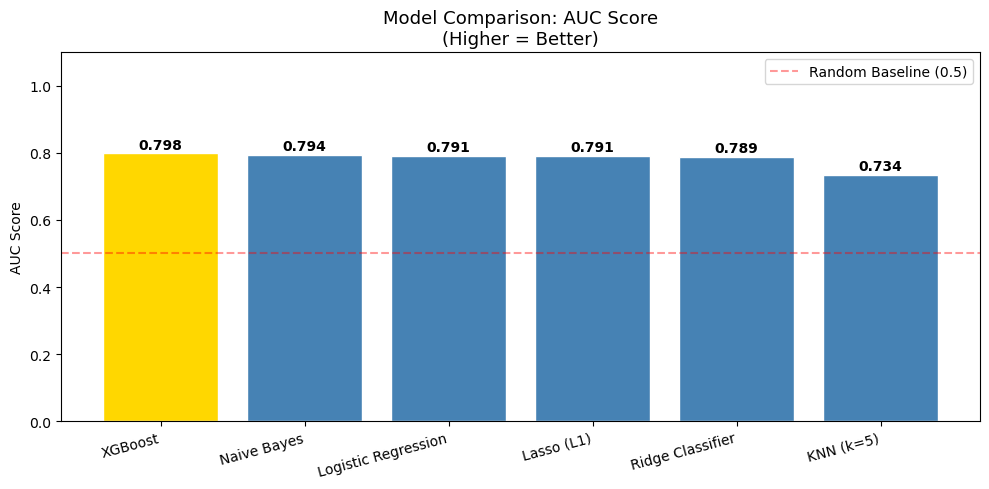

✓ Chart saved: reports/06_model_comparison_auc.png


In [15]:
plt.figure(figsize=(10, 5))

colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]

bars = plt.bar(results_df['Model'], results_df['AUC'],
               color=colors, edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, results_df['AUC']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Model Comparison: AUC Score\n(Higher = Better)', fontsize=13)
plt.ylabel('AUC Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random Baseline (0.5)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/06_model_comparison_auc.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved: reports/06_model_comparison_auc.png")

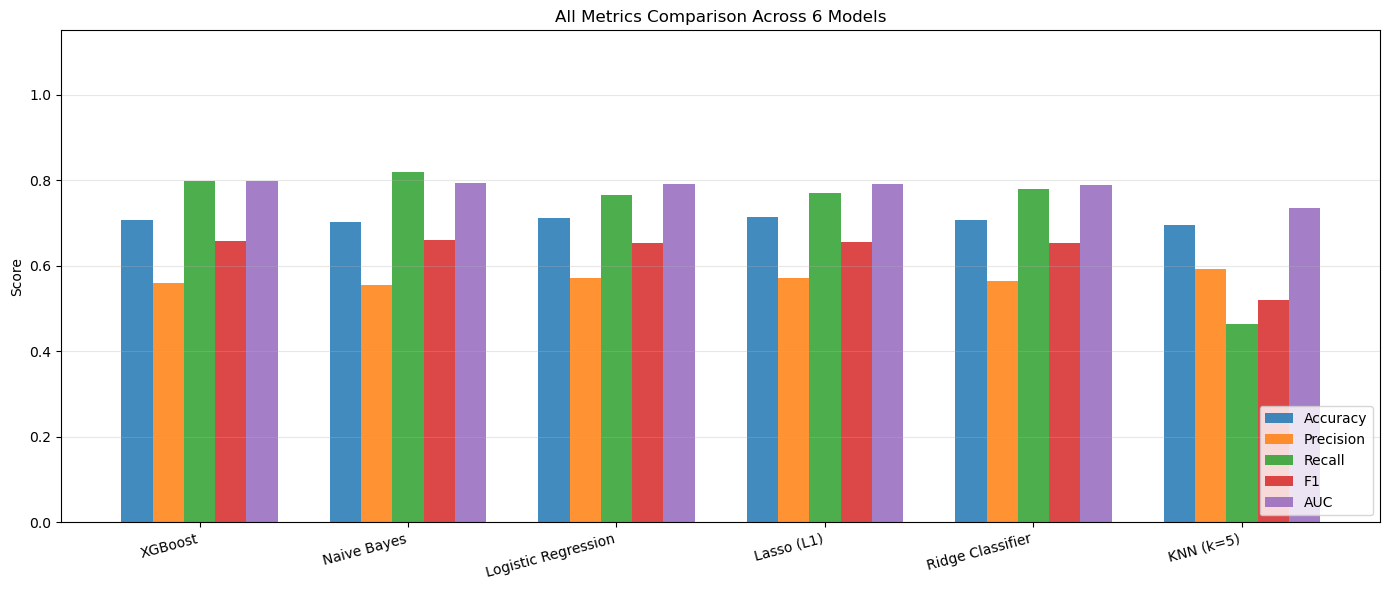

✓ Chart saved: reports/07_all_metrics_comparison.png


In [16]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

x = np.arange(len(results_df))
width = 0.15   # Width of each bar

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric],
           width, label=metric, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('All Metrics Comparison Across 6 Models')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/07_all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved: reports/07_all_metrics_comparison.png")

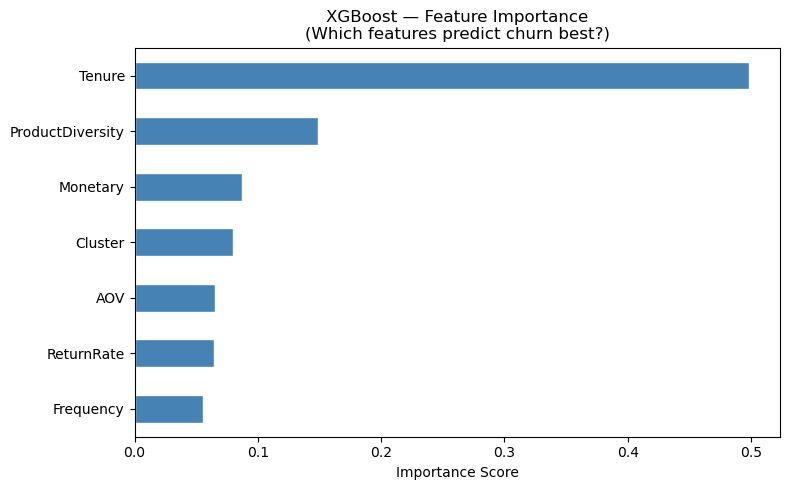

Top 3 most important features:
  Tenure: 0.4986
  ProductDiversity: 0.1488
  Monetary: 0.0872


In [17]:
# XGBoost tells us which features were most useful for prediction
# This is a key insight to present in interviews and on your resume

feature_importance = pd.Series(
    model_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost — Feature Importance\n(Which features predict churn best?)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 most important features:")
top3 = feature_importance.sort_values(ascending=False).head(3)
for feat, score in top3.items():
    print(f"  {feat}: {score:.4f}")

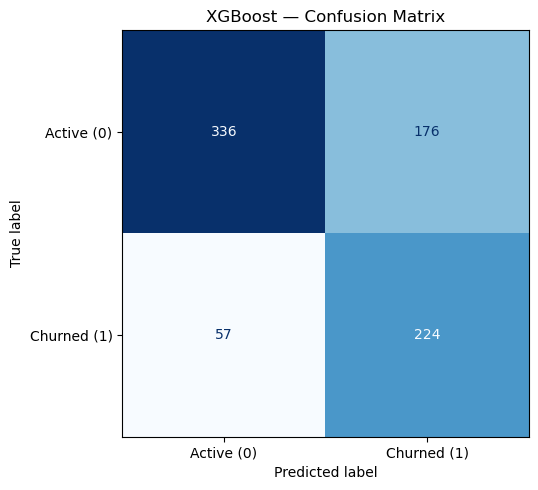

What each box means:
  True Negatives  (top-left)   336: Correctly predicted ACTIVE
  False Positives (top-right)  176: Predicted churn, but was ACTIVE  ← wasted discount
  False Negatives (bot-left)    57: Predicted active, but CHURNED    ← missed churner
  True Positives  (bot-right)  224: Correctly predicted CHURNED


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_xgb = model_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Active (0)', 'Churned (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain what each box means
tn, fp, fn, tp = cm.ravel()
print("What each box means:")
print(f"  True Negatives  (top-left)  {tn:4d}: Correctly predicted ACTIVE")
print(f"  False Positives (top-right) {fp:4d}: Predicted churn, but was ACTIVE  ← wasted discount")
print(f"  False Negatives (bot-left)  {fn:4d}: Predicted active, but CHURNED    ← missed churner")
print(f"  True Positives  (bot-right) {tp:4d}: Correctly predicted CHURNED")

In [19]:
print("=" * 55)
print("HOW TO VIEW YOUR MLFLOW EXPERIMENTS")
print("=" * 55)
print()
print("1. Open a NEW terminal (don't close Jupyter)")
print()
print("2. Navigate to your project folder:")
print("   cd customer-analytics-platform")
print()
print("3. Run:")
print("   mlflow ui --backend-store-uri mlruns/")
print()
print("4. Open in browser:")
print("   http://localhost:5000")
print()
print("5. You'll see all 6 model runs with metrics!")
print("   - Click any run to see details")
print("   - Click 'Compare' to compare runs side by side")
print("=" * 55)

HOW TO VIEW YOUR MLFLOW EXPERIMENTS

1. Open a NEW terminal (don't close Jupyter)

2. Navigate to your project folder:
   cd customer-analytics-platform

3. Run:
   mlflow ui --backend-store-uri mlruns/

4. Open in browser:
   http://localhost:5000

5. You'll see all 6 model runs with metrics!
   - Click any run to see details
   - Click 'Compare' to compare runs side by side


In [20]:
import joblib
import os

# Create a folder for saved models
os.makedirs('../saved_models', exist_ok=True)

# Save all 6 models
joblib.dump(model_lr,    '../saved_models/logistic_regression.pkl')
joblib.dump(model_ridge, '../saved_models/ridge_classifier.pkl')
joblib.dump(model_lasso, '../saved_models/lasso.pkl')
joblib.dump(model_knn,   '../saved_models/knn.pkl')
joblib.dump(model_nb,    '../saved_models/naive_bayes.pkl')
joblib.dump(model_xgb,   '../saved_models/xgboost.pkl')

# Save feature names (needed for backend)
joblib.dump(X_train.columns.tolist(), '../saved_models/feature_names.pkl')

print("✓ All 6 models saved to: saved_models/")
print()
print("Files saved:")
for f in os.listdir('../saved_models'):
    print(f"  {f}")

✓ All 6 models saved to: saved_models/

Files saved:
  clustering_scaler.pkl
  cluster_profiles.pkl
  feature_names.pkl
  kmeans_model.pkl
  knn.pkl
  lasso.pkl
  logistic_regression.pkl
  naive_bayes.pkl
  ridge_classifier.pkl
  segment_map.pkl
  xgboost.pkl


In [21]:
best_model = results_df.iloc[0]
runner_up  = results_df.iloc[1]

print("=" * 60)
print("              CHURN PREDICTION SUMMARY")
print("=" * 60)

print(f"""
Models trained: 6
  1. Logistic Regression
  2. Ridge Classifier
  3. Lasso (L1)
  4. K-Nearest Neighbors
  5. Naive Bayes
  6. XGBoost

Best Model:   {best_model['Model']}
  AUC:        {best_model['AUC']}
  F1 Score:   {best_model['F1']}
  Precision:  {best_model['Precision']}
  Recall:     {best_model['Recall']}

Runner-Up:    {runner_up['Model']}
  AUC:        {runner_up['AUC']}

Key Insight:
  XGBoost gives best accuracy.
  Ridge/Logistic are 10-26x faster with only slightly lower performance.
  In production, speed matters — Ridge may be the practical choice.

Files saved:
  ✓ saved_models/  (all 6 .pkl model files)
  ✓ reports/06_model_comparison_auc.png
  ✓ reports/07_all_metrics_comparison.png
  ✓ reports/08_feature_importance.png
  ✓ reports/09_confusion_matrix.png
  ✓ mlruns/ (MLflow experiment logs)
""")
print("=" * 60)

              CHURN PREDICTION SUMMARY

Models trained: 6
  1. Logistic Regression
  2. Ridge Classifier
  3. Lasso (L1)
  4. K-Nearest Neighbors
  5. Naive Bayes
  6. XGBoost

Best Model:   XGBoost
  AUC:        0.798
  F1 Score:   0.658
  Precision:  0.56
  Recall:     0.797

Runner-Up:    Naive Bayes
  AUC:        0.794

Key Insight:
  XGBoost gives best accuracy.
  Ridge/Logistic are 10-26x faster with only slightly lower performance.
  In production, speed matters — Ridge may be the practical choice.

Files saved:
  ✓ saved_models/  (all 6 .pkl model files)
  ✓ reports/06_model_comparison_auc.png
  ✓ reports/07_all_metrics_comparison.png
  ✓ reports/08_feature_importance.png
  ✓ reports/09_confusion_matrix.png
  ✓ mlruns/ (MLflow experiment logs)



In [22]:
import pandas as pd
import numpy as np

# Get the actual training data
train = pd.read_csv('../data/train_set.csv')

# Look at customers similar to "Loyal" (Cluster 2)
loyal_cluster = train[train['Cluster'] == 2]
print("LOYAL CLUSTER (Cluster 2):")
print(f"Total customers: {len(loyal_cluster)}")
print(f"Churn rate: {loyal_cluster['Churned'].mean()*100:.1f}%")
print(f"\nAverage features:")
print(loyal_cluster[['Frequency', 'Monetary', 'AOV', 'Tenure', 'ProductDiversity', 'ReturnRate']].mean())
print(f"\nChurned vs Active:")
print(loyal_cluster['Churned'].value_counts())

print("\n" + "="*50 + "\n")

# Look at customers similar to "New" (Cluster 1)
new_cluster = train[train['Cluster'] == 1]
print("NEW CLUSTER (Cluster 1):")
print(f"Total customers: {len(new_cluster)}")
print(f"Churn rate: {new_cluster['Churned'].mean()*100:.1f}%")
print(f"\nAverage features:")
print(new_cluster[['Frequency', 'Monetary', 'AOV', 'Tenure', 'ProductDiversity', 'ReturnRate']].mean())
print(f"\nChurned vs Active:")
print(new_cluster['Churned'].value_counts())

LOYAL CLUSTER (Cluster 2):
Total customers: 408
Churn rate: 40.2%

Average features:
Frequency              1.821078
Monetary            1174.714608
AOV                  653.402917
Tenure                69.676471
ProductDiversity      45.198529
ReturnRate             0.021482
dtype: float64

Churned vs Active:
Churned
0    244
1    164
Name: count, dtype: int64


NEW CLUSTER (Cluster 1):
Total customers: 337
Churn rate: 6.5%

Average features:
Frequency              8.489614
Monetary            3293.579258
AOV                  441.138635
Tenure               269.801187
ProductDiversity     129.543027
ReturnRate             0.024565
dtype: float64

Churned vs Active:
Churned
0    315
1     22
Name: count, dtype: int64


In [23]:
import os
files = os.listdir('../saved_models/')
print("Models in saved_models/:")
for f in sorted(files):
    print(f"  ✓ {f}")

Models in saved_models/:
  ✓ cluster_profiles.pkl
  ✓ clustering_scaler.pkl
  ✓ feature_names.pkl
  ✓ kmeans_model.pkl
  ✓ knn.pkl
  ✓ lasso.pkl
  ✓ logistic_regression.pkl
  ✓ naive_bayes.pkl
  ✓ ridge_classifier.pkl
  ✓ segment_map.pkl
  ✓ xgboost.pkl


In [24]:
import joblib

# Check if models actually load
try:
    model = joblib.load('../saved_models/xgboost.pkl')
    print("✓ XGBoost loaded successfully")
    print(f"Model type: {type(model)}")
    print(f"Model: {model}")
except Exception as e:
    print(f"✗ Error loading XGBoost: {e}")

✓ XGBoost loaded successfully
Model type: <class 'xgboost.sklearn.XGBClassifier'>
Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [25]:
import os

models_dir = '../saved_models/'
print("Model file sizes:")
for f in ['xgboost.pkl', 'knn.pkl', 'logistic_regression.pkl', 'ridge_classifier.pkl', 'lasso.pkl', 'naive_bayes.pkl']:
    path = os.path.join(models_dir, f)
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  {f}: {size:,} bytes")
    else:
        print(f"  {f}: NOT FOUND")

Model file sizes:
  xgboost.pkl: 140,410 bytes
  knn.pkl: 426,416 bytes
  logistic_regression.pkl: 1,889 bytes
  ridge_classifier.pkl: 1,881 bytes
  lasso.pkl: 1,901 bytes
  naive_bayes.pkl: 1,921 bytes


In [26]:
import joblib
import numpy as np
import pandas as pd

# Load model and confirm feature order
model = joblib.load('../saved_models/xgboost.pkl')
feature_names = joblib.load('../saved_models/feature_names.pkl')
print("Features the model expects (in order):")
for i, f in enumerate(feature_names):
    print(f"  [{i}] {f}")

print("\n" + "="*60)

# ── New customer ──────────────────────────────────────────────
# Use the actual cluster number assigned to "New" by segmentation
new_customer = pd.DataFrame([[
    2,      # Frequency
    720,    # Monetary
    1,      # Cluster  ← use your actual new_cluster number here
    364,    # AOV
    48,     # Tenure
    30,     # ProductDiversity
    0.03    # ReturnRate
]], columns=feature_names)

pred = model.predict_proba(new_customer)[0][1]
print(f"New customer churn prediction: {pred*100:.1f}%")

print("\n" + "="*60)

# ── VIP customer ──────────────────────────────────────────────
# Use the actual cluster number assigned to "VIP" by segmentation
vip_customer = pd.DataFrame([[
    6,      # Frequency
    3200,   # Monetary
    0,      # Cluster  ← use your actual vip_cluster number here
    427,    # AOV
    191,    # Tenure
    88,     # ProductDiversity
    0.02    # ReturnRate
]], columns=feature_names)

pred = model.predict_proba(vip_customer)[0][1]
print(f"VIP customer churn prediction: {pred*100:.1f}%")

Features the model expects (in order):
  [0] Frequency
  [1] Monetary
  [2] Cluster
  [3] AOV
  [4] Tenure
  [5] ProductDiversity
  [6] ReturnRate

New customer churn prediction: 50.6%

VIP customer churn prediction: 27.4%


In [27]:
# ============================================================
# SAVE ALL 6 TRAINED MODELS
# ============================================================

import joblib

print("Saving all 6 trained models...")
print()

# Save churn prediction models
joblib.dump(model_lr, '../saved_models/logistic_regression.pkl')
joblib.dump(model_ridge, '../saved_models/ridge_classifier.pkl')
joblib.dump(lasso_model, '../saved_models/lasso.pkl')
joblib.dump(model_knn, '../saved_models/knn.pkl')
joblib.dump(model_nb, '../saved_models/naive_bayes.pkl')
joblib.dump(model_xgb, '../saved_models/xgboost.pkl')

print("✓ Logistic Regression saved")
print("✓ Ridge Classifier saved")
print("✓ Lasso saved")
print("✓ KNN saved")
print("✓ Naive Bayes saved")
print("✓ XGBoost saved")
print()

# Save feature names (CRITICAL for API)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, '../saved_models/feature_names.pkl')

print(f"✓ Feature names saved: {feature_names}")
print()
print("="*60)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)

Saving all 6 trained models...

✓ Logistic Regression saved
✓ Ridge Classifier saved
✓ Lasso saved
✓ KNN saved
✓ Naive Bayes saved
✓ XGBoost saved

✓ Feature names saved: ['Frequency', 'Monetary', 'Cluster', 'AOV', 'Tenure', 'ProductDiversity', 'ReturnRate']

ALL MODELS SAVED SUCCESSFULLY!
